# anomaly-gpt: Financial Anomaly Detection via GPT Perplexity

This notebook demonstrates the full pipeline:
1. Data loading and return tokenization
2. Anomaly scoring with the trained GPT
3. Baseline comparison across 7 documented market crises
4. False-positive-rate control and a permutation test
5. VIX correlation analysis

Every number here is computed in-notebook from committed artifacts
(`anomaly_scores.csv`) or regenerated by `scripts/`. Nothing is typed by hand.

The ablation sweep is not reported: it was originally run without seeding, so
its numbers were not reproducible and the claims resting on them have been
withdrawn. See `FINDINGS.md`.


In [1]:
import os, sys

# Idempotent: walk up to the repo root instead of chdir('..') every run.
while not os.path.exists('gpt/model.py') and os.getcwd() != '/':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('Working directory:', os.getcwd())


Working directory: /Users/aria/Desktop/unige/Projects/anomaly-gpt


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.12.0
Device: cpu


## 1. Data Pipeline

We discretize continuous log-returns into a 3-token alphabet:
- **0 (down):** r < -0.01
- **1 (flat):** -0.01 ≤ r < +0.01  
- **2 (up):** r ≥ +0.01

This transforms a time series prediction problem into a language modeling problem.

In [3]:
from data.loader import load_all_assets, train_val_split
from data.tokenizer import ReturnTokenizer

# Load all 5 assets
tickers = {"SPY": "SPY", "QQQ": "QQQ", "GLD": "GLD", "TLT": "TLT", "VIX": "^VIX"}
all_returns = {}
for label, ticker in tickers.items():
    from data.loader import download_returns
    all_returns[label] = download_returns(ticker)

spy = all_returns["SPY"]
print(f"SPY: {len(spy)} trading days ({spy.index[0].date()} → {spy.index[-1].date()})")
print(f"\nReturn statistics:")
print(spy.describe().round(4))

SPY: 3521 trading days (2010-01-05 → 2023-12-29)

Return statistics:
count    3521.0000
mean        0.0005
std         0.0109
min        -0.1159
25%        -0.0038
50%         0.0007
75%         0.0058
max         0.0867
Name: SPY, dtype: float64


Token distribution (SPY 2010–2024):
   down: ████ 11.4%
   flat: ██████████████████████████████ 75.3%
     up: █████ 13.3%


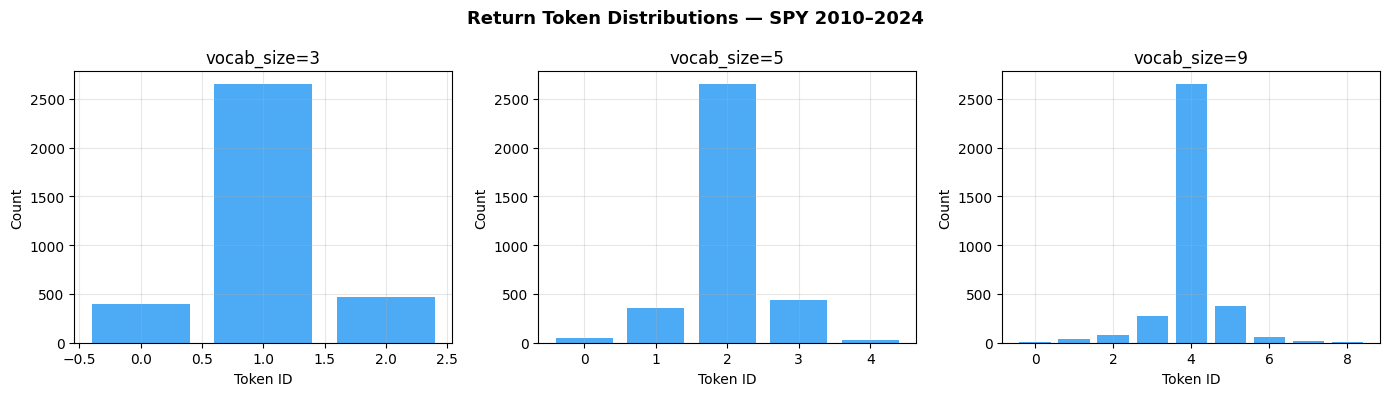

In [4]:
# Tokenization demo
tok = ReturnTokenizer(vocab_size=3)
token_ids = tok.encode(spy.values)
dist = tok.bin_distribution(spy.values)

print("Token distribution (SPY 2010–2024):")
for label, frac in dist.items():
    bar = '█' * int(frac * 40)
    print(f"  {label:>5}: {bar} {frac:.1%}")

# Compare vocab sizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, v in zip(axes, [3, 5, 9]):
    t = ReturnTokenizer(vocab_size=v)
    ids = t.encode(spy.values)
    counts = pd.Series(ids).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#2196F3', alpha=0.8)
    ax.set_title(f'vocab_size={v}', fontsize=12)
    ax.set_xlabel('Token ID')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
fig.suptitle('Return Token Distributions — SPY 2010–2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Ablation — withdrawn pending a seeded re-run

The 3x3 grid over vocabulary size and context length was run without seeding.
Re-running a single configuration under three seeds moved validation loss by
about 0.004, which is larger than several of the differences the original
findings were built on, so those findings have been removed.

Validation loss is also not comparable across vocabulary sizes: different
tokenizations have different marginal entropies, so a lower loss at vocab=3
is substantially a property of the alphabet rather than of generalisation.

`experiments/run_sweep.py` is now seeded and runs each grid point across
multiple seeds. `experiments/results.csv` is a pre-seeding artifact and is
deliberately not loaded here.


## 3. Anomaly Scoring

The trained GPT assigns a perplexity score to each day: how surprised is the model by today's return given the past 20 days?

In [5]:
# Load pre-computed anomaly scores (from trained model)
scores = pd.read_csv('anomaly_scores.csv', index_col='Date', parse_dates=True)

print(f"Anomaly scores shape: {scores.shape}")
print(f"Date range: {scores.index[0].date()} → {scores.index[-1].date()}")
print(f"Assets: {list(scores.columns)}")
print(f"\nScore statistics:")
print(scores.describe().round(4))

Anomaly scores shape: (3501, 5)
Date range: 2010-02-03 → 2023-12-29
Assets: ['SPY', 'QQQ', 'VIX', 'GLD', 'TLT']

Score statistics:
             SPY        QQQ        VIX        GLD        TLT
count  3501.0000  3501.0000  3501.0000  3501.0000  3501.0000
mean      0.6478     0.8149     1.2360     0.7532     0.7811
std       0.4701     0.4384     0.1611     0.4247     0.4336
min       0.0805     0.0805     0.5982     0.0805     0.0805
25%       0.1049     0.5935     1.1279     0.4961     0.5254
50%       0.7084     0.8329     1.2210     0.7568     0.7895
75%       1.0093     1.1317     1.3297     1.0158     1.0737
max       2.4534     2.3357     2.0572     2.4343     2.9090


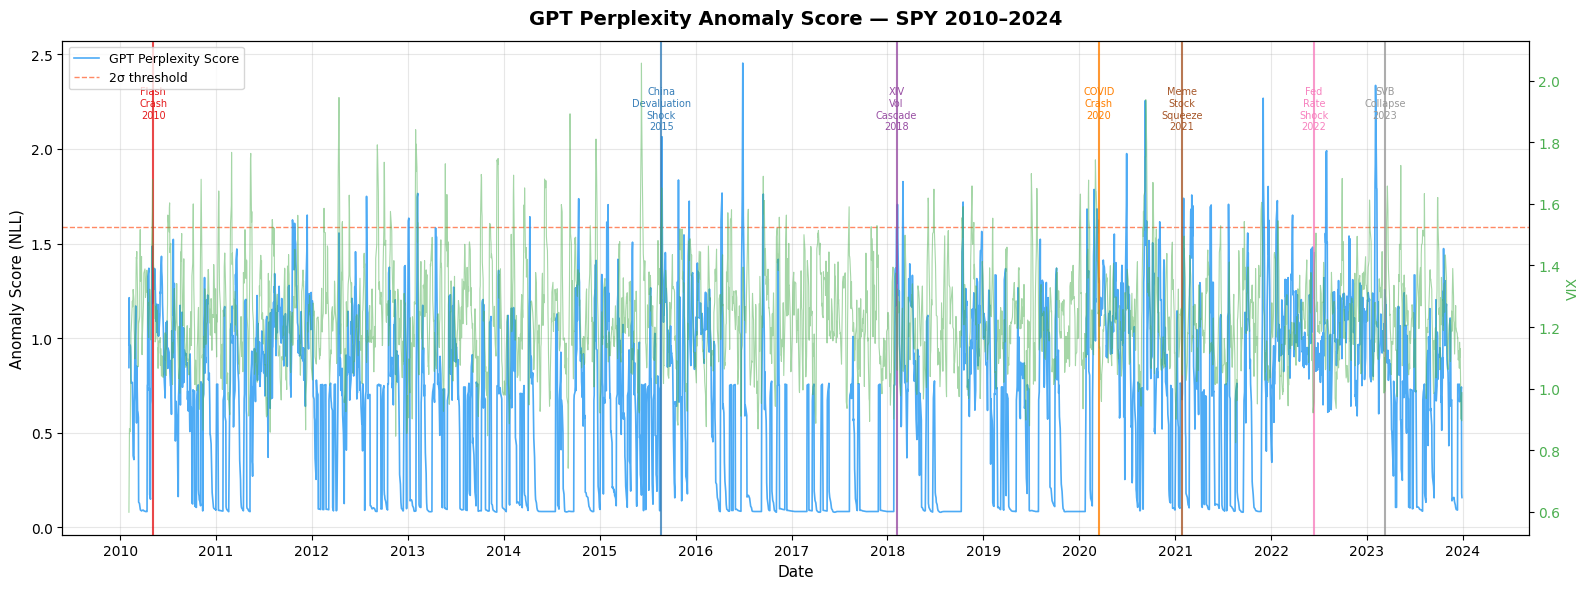

In [6]:
from viz.plot import plot_anomaly_timeline

fig = plot_anomaly_timeline(
    scores['SPY'],
    title='GPT Perplexity Anomaly Score — SPY 2010–2024',
    vix=scores['VIX'],
    figsize=(16, 6),
)
plt.show()

## 4. Baseline Comparison

We compare GPT perplexity against three baselines on all 7 documented market crises.

In [7]:
from anomaly.events import EVENTS
from anomaly.detector import score_event_window
from anomaly.baselines import RollingVolatility, EWMAVolatility, IsolationForestDetector

returns = all_returns['SPY']

# Fit baselines on pre-COVID data
train_returns = returns[returns.index < '2020-01-01']

rv   = RollingVolatility(window=20).fit(returns)
ewma = EWMAVolatility(span=20).fit(returns)
iso  = IsolationForestDetector(n_lags=20).fit(train_returns)

rv_scores   = rv.score(returns).dropna()
ewma_scores = ewma.score(returns).dropna()
iso_scores  = iso.score(returns).dropna()

detectors = {
    'GPT Perplexity':   scores['SPY'],
    'Rolling Vol':      rv_scores,
    'EWMA Vol':         ewma_scores,
    'Isolation Forest': iso_scores,
}

# Detection table
print(f"{'Event':<30} {'GPT':>6} {'RVol':>6} {'EWMA':>6} {'ISO':>6}")
print('-' * 58)
for event in EVENTS:
    row = f'{event.name:<30}'
    for name, s in detectors.items():
        r = score_event_window(s, event.window_start, event.window_end)
        row += f' {"YES":>6}' if r['detected'] else f' {"no":>6}'
    print(row)

print()
print('Detection counts:')
for name, s in detectors.items():
    count = sum(
        1 for e in EVENTS
        if score_event_window(s, e.window_start, e.window_end)['detected']
    )
    bar = '█' * count
    print(f'  {name:<20} {bar} {count}/7')

Event                             GPT   RVol   EWMA    ISO
----------------------------------------------------------
Flash Crash 2010                   no     no     no     no
China Devaluation Shock 2015      YES     no    YES     no
XIV Vol Cascade 2018              YES     no     no     no
COVID Crash 2020                  YES    YES    YES    YES
Meme Stock Squeeze 2021           YES     no     no     no
Fed Rate Shock 2022                no     no     no    YES
SVB Collapse 2023                  no     no     no     no

Detection counts:
  GPT Perplexity       ████ 4/7
  Rolling Vol          █ 1/7
  EWMA Vol             ██ 2/7
  Isolation Forest     ██ 2/7


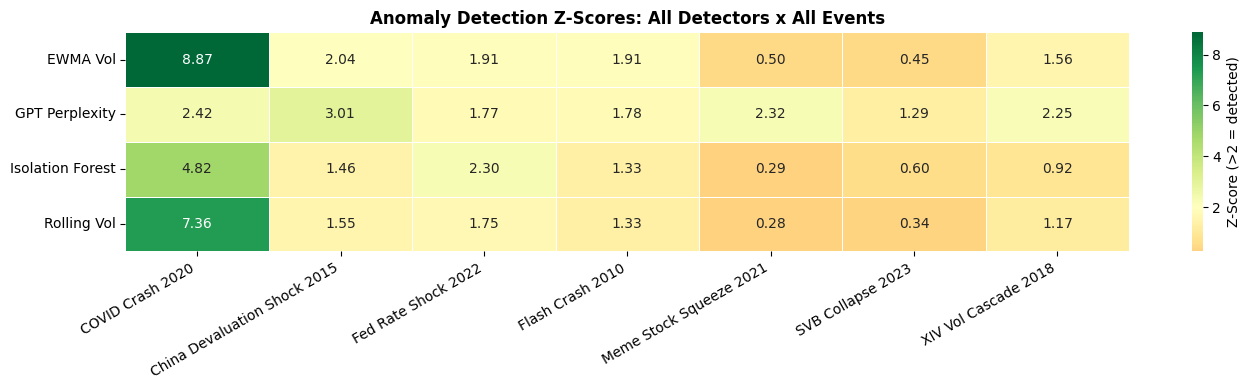


Detection rate summary:
                  detected  total  detection_rate
detector                                         
GPT Perplexity           4      7        0.571429
EWMA Vol                 2      7        0.285714
Isolation Forest         2      7        0.285714
Rolling Vol              1      7        0.142857


In [8]:
from eval.harness import run_full_harness, detection_counts
from viz.heatmap import plot_detection_heatmap

baseline_scores = {
    'Rolling Vol':      rv_scores,
    'EWMA Vol':         ewma_scores,
    'Isolation Forest': iso_scores,
}

results_df = run_full_harness(scores['SPY'], baseline_scores)
fig = plot_detection_heatmap(results_df, figsize=(14, 4))
plt.show()

print("\nDetection rate summary:")
print(detection_counts(results_df))

## 4. Event Deep-Dives

Zoomed view of events where GPT and the baselines diverge. The events GPT
detects and the baselines do not are XIV Vol Cascade 2018, China Devaluation
2015 and Meme Stock Squeeze 2021.

No mechanism is claimed for why these events and not others: with n=7 there
is no power to test one.


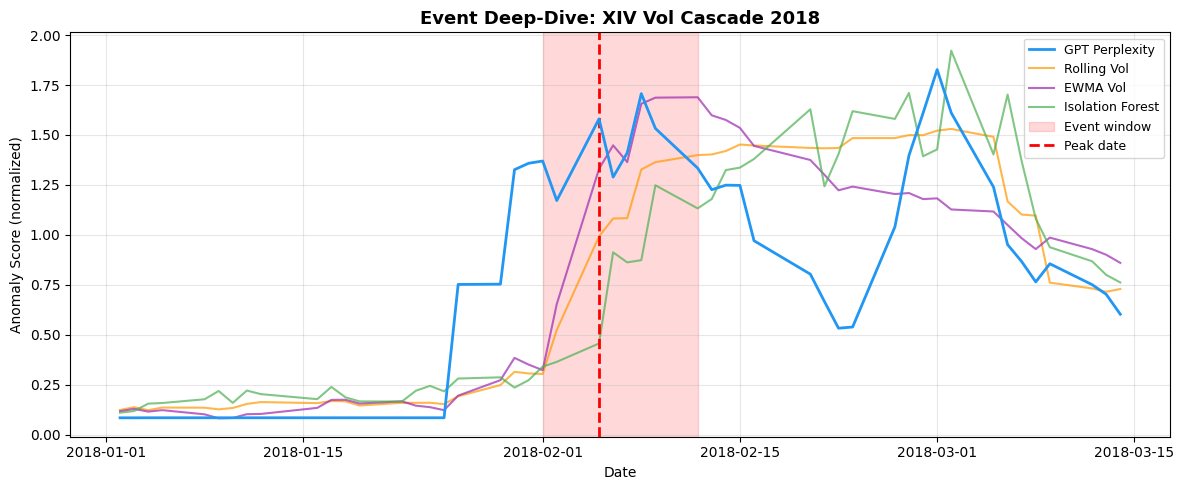

XIV Vol Cascade — GPT z-score: 2.25 | Detected: True


In [9]:
from viz.plot import plot_event_zoom
from anomaly.events import get_event

# XIV Vol Cascade 2018 — detected by GPT, missed by all baselines
event = get_event('XIV Vol Cascade 2018')
fig = plot_event_zoom(
    scores['SPY'],
    event,
    all_scores=baseline_scores,
    figsize=(12, 5),
)
plt.show()

r = score_event_window(scores['SPY'], event.window_start, event.window_end)
print(f"XIV Vol Cascade — GPT z-score: {r['z_score']:.2f} | Detected: {r['detected']}")


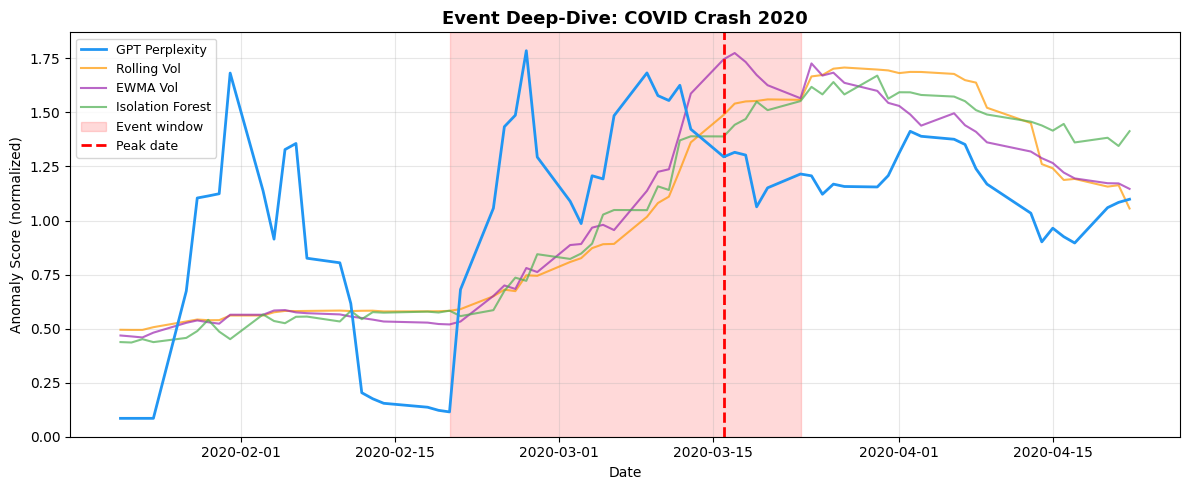

COVID Crash — GPT z-score: 2.42 | Detected: True


In [10]:
# COVID Crash — detected by all
event = get_event('COVID Crash 2020')
fig = plot_event_zoom(
    scores['SPY'],
    event,
    all_scores=baseline_scores,
    figsize=(12, 5),
)
plt.show()

r = score_event_window(scores['SPY'], event.window_start, event.window_end)
print(f"COVID Crash — GPT z-score: {r['z_score']:.2f} | Detected: {r['detected']}")

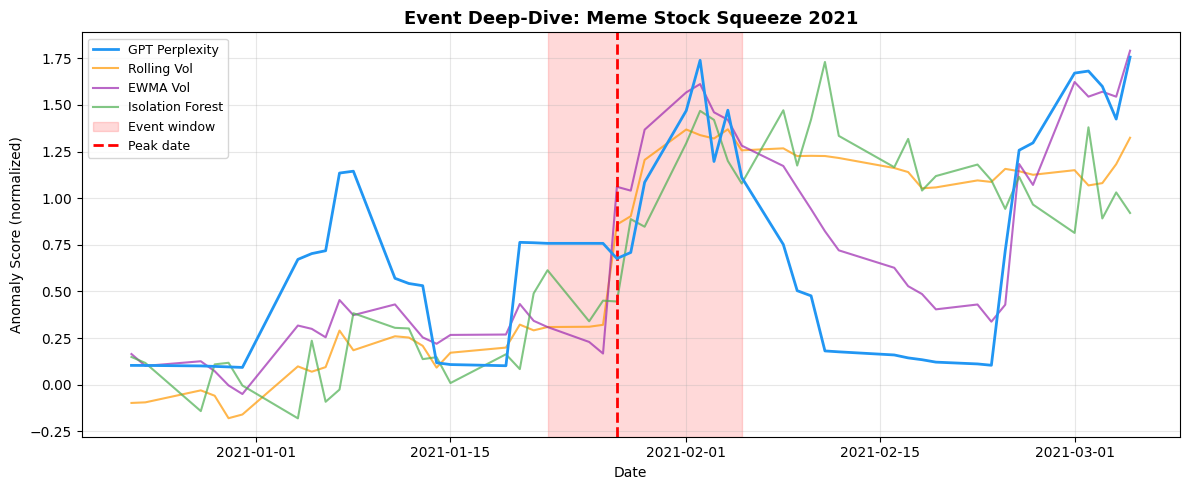

Meme Stock Squeeze — GPT z-score: 2.32 | Detected: True


In [11]:
# Meme Stock Squeeze — GPT detects, all baselines miss
event = get_event('Meme Stock Squeeze 2021')
fig = plot_event_zoom(
    scores['SPY'],
    event,
    all_scores=baseline_scores,
    figsize=(12, 5),
)
plt.show()

r = score_event_window(scores['SPY'], event.window_start, event.window_end)
print(f"Meme Stock Squeeze — GPT z-score: {r['z_score']:.2f} | Detected: {r['detected']}")

## 6. VIX Correlation Analysis

How well does GPT perplexity correlate with VIX (the market's fear gauge)?

=== VIX Correlation Report ===
Pearson  r   = -0.037  (p=2.665e-02, n=3501)
Spearman rho = -0.098  (p=7.390e-09)
Best lag     = -4 days  (rho=0.052)
Interpretation: GPT leads VIX

Best lag: -4 days (rho=0.052)
Interpretation: GPT leads VIX


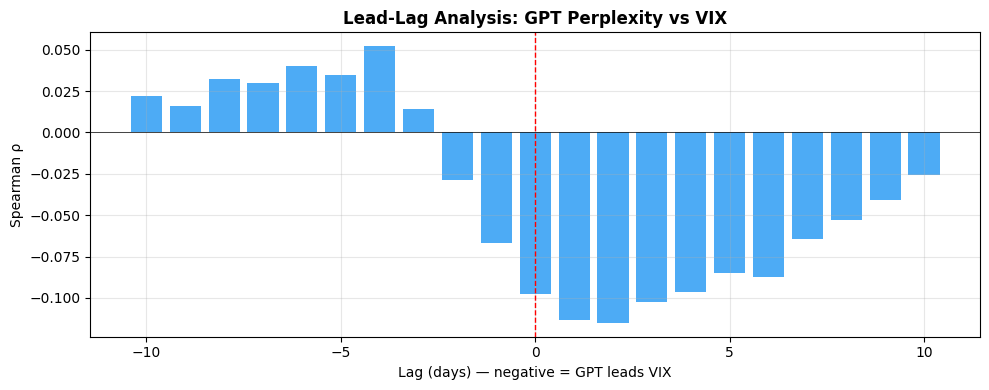

In [12]:
from eval.vix_correlation import correlation_report, lead_lag_analysis

vix_returns = all_returns['VIX']
spy_scores  = scores['SPY']

print(correlation_report(spy_scores, vix_returns))

# Lead-lag analysis
lag_df = lead_lag_analysis(spy_scores, vix_returns, max_lag=10)
best   = lag_df.loc[lag_df['spearman_rho'].idxmax()]
print(f"\nBest lag: {best['lag']} days (rho={best['spearman_rho']:.3f})")
print(f"Interpretation: {best['interpretation']}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag'], lag_df['spearman_rho'], color='#2196F3', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (days) — negative = GPT leads VIX')
ax.set_ylabel('Spearman ρ')
ax.set_title('Lead-Lag Analysis: GPT Perplexity vs VIX', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

Computed below from the detection table built earlier in this notebook — no
values are typed in. See `FINDINGS.md` for the full write-up and the command
that generates each number.


In [13]:
from anomaly.detector import flag_rate
from scripts.run_eval import circular_shift_null
from scripts.score_assets import load_model, resolve_checkpoint

# load the published checkpoint so the parameter count is traceable
model, ckpt_cfg = load_model(resolve_checkpoint())

detectors = {'GPT Perplexity': scores['SPY'], **baseline_scores}

print("=" * 62)
print("SUMMARY — all values computed, none hardcoded")
print("=" * 62)
print(f"Model parameters : {model.param_count():,}")
print(f"Config           : vocab={ckpt_cfg['vocab_size']} context={ckpt_cfg['context_length']}")
print(f"Evaluation period: {scores.index[0].date()} to {scores.index[-1].date()}")
print(f"Assets scored    : {', '.join(scores.columns)}")
print(f"Events evaluated : {len(EVENTS)}")
print()

counts = detection_counts(results_df)
print("Detections at z > 2, with implied false-positive rate:")
for name, s in detectors.items():
    hits = int(counts.loc[name, 'detected']) if name in counts.index else None
    print(f"  {name:<26} {hits}/{len(EVENTS)}   flags {flag_rate(s):.2%} of days")

print()
print("Circular-shift null (1000 shifts):")
for name, s in detectors.items():
    r = circular_shift_null(s, n_shifts=1000)
    print(f"  {name:<26} observed {r['observed']}/{len(EVENTS)}   p = {r['p_value']:.3f}")
print("=" * 62)


SUMMARY — all values computed, none hardcoded
Model parameters : 200,768
Config           : vocab=3 context=20
Evaluation period: 2010-02-03 to 2023-12-29
Assets scored    : SPY, QQQ, VIX, GLD, TLT
Events evaluated : 7

Detections at z > 2, with implied false-positive rate:
  GPT Perplexity             4/7   flags 2.11% of days
  Rolling Vol                1/7   flags 2.05% of days
  EWMA Vol                   2/7   flags 2.61% of days
  Isolation Forest           2/7   flags 5.46% of days

Circular-shift null (1000 shifts):


  GPT Perplexity             observed 4/7   p = 0.004


  Rolling Vol                observed 1/7   p = 0.148


  EWMA Vol                   observed 2/7   p = 0.049


  Isolation Forest           observed 2/7   p = 0.134
